In [33]:
# This file is mainly used for doing stream statistics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from WFlib.utils.statistics import IQR_bound

def stream_numbers_fetch(db: pd.DataFrame, protocol: str, host: str):
    """
    Get the number of streams for the given protocol and host.
    """
    groups = db[(db['protocol'] == protocol) & (db['host'] == host)].groupby('id')
    stream_numbers = []
    for _, group in groups:
        stream_numbers.append(group.shape[0])
    return np.array(stream_numbers)

def select_features_by_host(npz_file, host_name, feature_key='hsdbs'):
    """
    Select features for a specific host from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_name (str): The name of the host to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified host
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the index of the host in the hosts array
    host_indices = np.where(hosts == host_name)[0]
    
    if len(host_indices) == 0:
        raise ValueError(f"Host '{host_name}' not found in the dataset")
    
    # Get the label corresponding to this host (should be the same for all instances)
    host_label = labels[host_indices[0]]
    
    # Find all features where the label matches the host's label
    mask = labels == host_label
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

def select_features_by_hosts(npz_file, host_names, feature_key='hsdbs'):
    """
    Select features for multiple hosts from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_names (list): List of host names to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified hosts
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the labels corresponding to the requested hosts
    host_labels = []
    if isinstance(host_names, str):
        host_names = [host_names]
    for host_name in host_names:
        host_indices = np.where(hosts == host_name)[0]
        if len(host_indices) == 0:
            raise ValueError(f"Host '{host_name}' not found in the dataset")
        host_labels.append(host_indices.item())
    
    # Find all features where the label matches any of the requested host labels
    mask = (labels == host_labels)
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

In [2]:
db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv")
hosts = db['host'].unique()
protocol = ["normal", "vmess"]

stream_numbers = dict()

for host in hosts:
    for p in protocol:
        stream_numbers[(host, p)] = stream_numbers_fetch(db, p, host)

In [3]:
# For each value of stream numbers, filter the outliers according to IQR.
for host in hosts:
    for p in protocol:
        lower_bound, upper_bound= IQR_bound(stream_numbers[(host, p)])
        stream_numbers[(host, p)] = stream_numbers[(host, p)][
            (stream_numbers[(host, p)] <= upper_bound) & (stream_numbers[(host, p)] >= lower_bound)
        ]

avg_stream_numbers = {key: np.mean(value) for key, value in stream_numbers.items()}
std_stream_numbers = {key: np.std(value) for key, value in stream_numbers.items()}

In [ ]:
dataset_path = "/data/exp/lxyu/Dataset/WF/datasets/shadowsocks_hsdbs.npz"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv").query("protocol == 'vmess'")

npz_file = np.load(dataset_path)

In [42]:
# select_features, select_labels = select_features_by_hosts(npz_file, "www.ieee.org", feature_key='hsdbs')
# features = npz_file['hsdbs'].flatten()
# features = features[features != 0]
# hist, bins = np.histogram(features, bins=list(range(-10742511, 284954, 1000)))

# # Create a boolean mask where True indicates non-zero elements
# mask = (features != 0)
# # Find the first False (0) in each row
# first_zero_indices = np.argmax(~mask, axis=1)
# # If there's no 0 in a row, argmax will return 0, so we need to handle that case
# first_zero_indices[mask.all(axis=1)] = features.shape[1]  # Set to length of row if no zeros found

In [44]:
select_features, select_labels = select_features_by_hosts(npz_file, "archive.org", feature_key='hsdbs')
# Create a boolean mask where True indicates non-zero elements
mask = (select_features != 0)
# Find the first False (0) in each row
first_zero_indices = np.argmax(~mask, axis=1)
# If there's no 0 in a row, argmax will return 0, so we need to handle that case
first_zero_indices[mask.all(axis=1)] = select_features.shape[1]  # Set to length of row if no zeros found

In [ ]:
import pandas as pd
from WFlib.tools.formatter import array_path
from WFlib.tools.extractor import NpzHSDBSExtractor
import numpy as np

extractor = NpzHSDBSExtractor(ignore_control_packets=True, threshold=0)

# base_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/arrays"
protocols = ['trojan', 'vmess', 'shadowsocks']
# stream_sizes = {p: [] for p in protocols}

snis = ['content-signature-2.cdn.mozilla.net', 'firefox-settings-attachments.cdn.mozilla.net', 'firefox.settings.services.mozilla.com']

versions = [137]

for version in versions:
    base_dir = f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/csv_db_extract/arrays"
    for sni in snis:
        stream_sizes = {p: [] for p in protocols}
        db = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/csv_db_extract/database.csv").query(f"sni == '{sni}'")

        db = db[['host', 'id', 'stream', 'transport', 'protocol']]
        for protocol in protocols:
            proto_db = db[db['protocol'] == protocol]
            paths = proto_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
            for path in paths:
                npz_file = np.load(path)
                bursts = extractor.single_stream_extract(npz_file)
                stream_sizes[protocol].append(sum([abs(size) for _, size in bursts]))

        # Add None as the padding values for the shorter lists.
        max_length = max(len(sizes) for sizes in stream_sizes.values())
        for protocol, sizes in stream_sizes.items():
            if len(sizes) < max_length:
                stream_sizes[protocol] = sizes + [None] * (max_length - len(sizes))

        pd.DataFrame(stream_sizes).to_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/{sni}.csv")
        

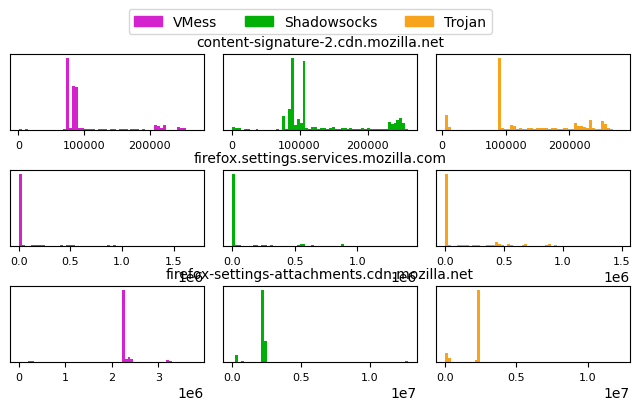

In [1]:
# Read in the following files:
# /home/lxyu/Reproduction/WFLib/exp/data_analysis/content-signature-2.cdn.mozilla.net.csv
# /home/lxyu/Reproduction/WFLib/exp/data_analysis/firefox.settings.services.mozilla.com.csv
# /home/lxyu/Reproduction/WFLib/exp/data_analysis/firefox-settings-attachments.cdn.mozilla.net.csv
# Each csv should be read in as a pandas dataframe.

# Now use the plt.hist to plot the histograms, the figure should be a 3x3 subplot, with the x-axis being the bins, and the y-axis being the count.
# Each row draws the 3 arrays of the same sni.
# The figure should be saved as a png file.
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

version = "whole"

dfs = dict()
dfs['content-signature-2.cdn.mozilla.net'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/content-signature-2.cdn.mozilla.net.csv")
dfs['firefox.settings.services.mozilla.com'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/firefox.settings.services.mozilla.com.csv")
dfs['firefox-settings-attachments.cdn.mozilla.net'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/firefox-settings-attachments.cdn.mozilla.net.csv")

# Each csv contains the same columns: trojan, vmess, shadowsocks
# For each csv, for each column, compute the histogram of the column, where the bins are of size 500.
arrays = {'content-signature-2.cdn.mozilla.net': [], 'firefox.settings.services.mozilla.com': [], 'firefox-settings-attachments.cdn.mozilla.net': []}
for sni in dfs:
    columns = [dfs[sni]['vmess'].dropna().to_numpy().astype(np.int64), dfs[sni]['shadowsocks'].dropna().to_numpy().astype(np.int64), dfs[sni]['trojan'].dropna().to_numpy().astype(np.int64)]
    arrays[sni] = columns

protocols = ["VMess", "Shadowsocks", "Trojan"]
color_map = ["#d422ce", "#00b006", "#f7a31b"]

patches = [mpatches.Patch(color=color_map[i], label=protocols[i]) for i in range(3)]

x_lim = [300000, .6e6, 4e6]
x_ticks = [range(0, 300000, 100000), range(0, int(.6e6), int(.2e6)), range(0, int(4e6), int(1e6))]

fig, axes = plt.subplots(3, 3, figsize=(8, 4))

for j in range(3):
    for i, sni in enumerate(dfs):
        # axes[i, j].hist(arrays[sni][j][arrays[sni][j] < x_lim[i]], bins=60, color=color_map[j], label=protocols[j])
        axes[i, j].hist(arrays[sni][j], bins=60, color=color_map[j], label=protocols[j])
        # axes[i, j].set_xlim(0, x_lim[i])
        axes[i, j].tick_params(axis='x', labelsize=8)
        # axes[j, i].tick_params(axis='y', labelsize=6)
        # Hide y-axis
        axes[i, j].set_yticks([])
        # axes[i, j].set_xticks(x_ticks[i])
        axes[i, 1].set_title(sni, fontsize=10)
            

# Manually create a legend for the whole figure
fig.legend(handles=patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.01), fontsize=10)

fig.subplots_adjust(hspace=0.53, wspace=0.1)
# plt.savefig('histograms.png')

plt.savefig('browser_noise.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [ ]:
import pandas as pd
from WFlib.tools.formatter import array_path
import numpy as np

def protocol_stream_length(protocol, db):
    """
    Given the protocol and database, compute the average stream length for each SNI.
    """
    protocol_stream_length = dict()
    base_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/arrays"
    protocol_db = db.query(f"protocol == '{protocol}'")
    for host in protocol_db['host'].unique():
        host_db = protocol_db.query(f"host == '{host}'")
        for sni in host_db['sni'].unique(): 
            sni_db = host_db.query(f"sni == '{sni}'")
            paths = sni_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
            for path in paths:
                if (host, sni) in protocol_stream_length:
                    protocol_stream_length[(host, sni)].append(np.load(path)['direction'].shape[0])
                else:
                    protocol_stream_length[(host, sni)] = [np.load(path)['direction'].shape[0]]
    return protocol_stream_length

db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv")

normal_stream_length = protocol_stream_length('normal', db)
vmess_stream_length = protocol_stream_length('vmess', db)
shadowsocks_stream_length = protocol_stream_length('shadowsocks', db)

In [31]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from WFlib.tools.formatter import array_path
from WFlib.utils.statistics import greedy_mass_covering

protocol = "trojan"
# whole
base_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/arrays"
db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv").query("protocol == @protocol")
# 134
# base_dir = "/data/exp/lxyu/Dataset/WF/firefox/134/VisualSeg/csv_db_extract/arrays"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/firefox/134/VisualSeg/csv_db_extract/database.csv").query("protocol == @protocol")
# 135
# base_dir = "/data/exp/lxyu/Dataset/WF/firefox/135/VisualSeg/csv_db_extract/arrays"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/firefox/135/VisualSeg/csv_db_extract/database.csv").query("protocol == @protocol")
# 136_new
# base_dir = "/data/exp/lxyu/Dataset/WF/firefox/136_new/VisualSeg/csv_db_extract/arrays"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/firefox/136_new/VisualSeg/csv_db_extract/database.csv").query("protocol == @protocol")
# 139
# base_dir = "/data/exp/lxyu/Dataset/WF/firefox/139/VisualSeg/csv_db_extract/arrays"
# db = pd.read_csv("/data/exp/lxyu/Dataset/WF/firefox/139/VisualSeg/csv_db_extract/database.csv").query("protocol == @protocol")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
intersect_sni = None
for host in db["host"].unique():
    host_db = db.query("host == @host")
    union_sni = set()
    for _, group in host_db.groupby("id"):
        # For each group, get the union of sni
        union_sni.update(group["sni"].unique())
    if intersect_sni is None:
        intersect_sni = union_sni
    else:
        intersect_sni = intersect_sni.intersection(union_sni)

In [33]:
# Given the protocol, for each sni in the intersect_sni, get the length of each array whose path computed by array_path.
sni_length = {sni: [] for sni in intersect_sni}
for sni in intersect_sni:
    sni_db = db.query("sni == @sni")
    paths = sni_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
    for path in paths:
        sni_length[sni].append(np.sum(np.load(path)['length']))

In [ ]:
sni_cover = {sni: [] for sni in sni_length}
# coverages = [.6, .7, .8, .9]
# for coverage in coverages:
#     for sni in sni_length:
#         cover, actual_coverage = greedy_mass_covering(sni_length[sni], 1000, coverage)
#         sni_cover[sni].append(cover)

for sni in sni_length:
    cover, actual_coverage = greedy_mass_covering(sni_length[sni], 1000, .8)
    sni_cover[sni].append(cover)

In [ ]:
sni_cover

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from WFlib.utils.statistics import greedy_mass_covering

versions = [v for v in range(132, 141)]
protocols = ["VMess", "Shadowsocks", "Trojan"]
color_map = ["#d422ce", "#00b006", "#f7a31b"]
coverage = .4

SNI_BIN_SIZE = {
    'firefox-settings-attachments.cdn.mozilla.net': 20000, 
    'firefox.settings.services.mozilla.com': 500, 
    'content-signature-2.cdn.mozilla.net': 1000
}

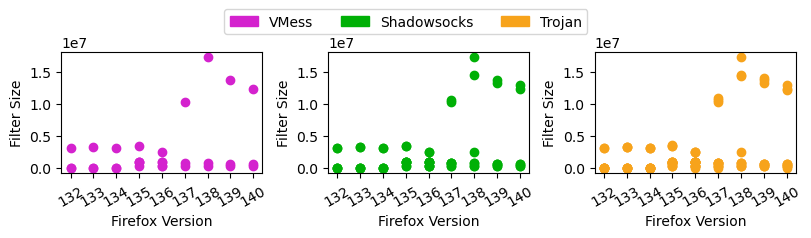

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2), constrained_layout=True)
patches = [mpatches.Patch(color=color_map[i], label=protocols[i]) for i in range(3)]

axs[0].set_xticks(versions)
axs[0].tick_params(axis='x', rotation=30)
axs[0].set_ylabel("Filter Size")
axs[0].set_xlabel("Firefox Version")
axs[1].set_xticks(versions)
axs[1].tick_params(axis='x', rotation=30)
axs[1].set_ylabel("Filter Size")
axs[1].set_xlabel("Firefox Version")
axs[2].set_xticks(versions)
axs[2].tick_params(axis='x', rotation=30)
axs[2].set_ylabel("Filter Size")
axs[2].set_xlabel("Firefox Version")
for version in versions:
    dfs = dict()
    dfs['content-signature-2.cdn.mozilla.net'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/content-signature-2.cdn.mozilla.net.csv")
    dfs['firefox.settings.services.mozilla.com'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/firefox.settings.services.mozilla.com.csv")
    dfs['firefox-settings-attachments.cdn.mozilla.net'] = pd.read_csv(f"/data/exp/lxyu/Dataset/WF/VisualSeg/firefox_dataset/{version}/firefox-settings-attachments.cdn.mozilla.net.csv")
    total_cover = []
    for i, protocol in enumerate(protocols):
        for sni in dfs:
            array = dfs[sni][protocol.lower()].dropna().to_numpy().astype(np.int64)
            cover, actual_coverage = greedy_mass_covering(array, SNI_BIN_SIZE[sni], coverage)
            total_cover += cover
        
        for cover in total_cover:
            axs[i].scatter(version, (cover[0] + cover[1])/2, color=color_map[i], marker='o')

fig.legend(handles=patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.15), fontsize=10)
plt.savefig('version.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [1]:
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

def compute_slope_above_threshold(array, threshold=80):
    """
    Compute the slope of the line segment where y >= threshold.
    
    Parameters:
    x: ndarray - x coordinates
    y: ndarray - y coordinates  
    threshold: float - minimum y value to consider (default: 80)
    
    Returns:
    slope: float - slope of the line segment where y >= threshold
    """
    # Find indices where y >= threshold
    mask = array >= threshold
    indices = np.where(mask)[0]
    
    if len(indices) < 2:
        raise ValueError(f"Need at least 2 points with y >= {threshold}")
    
    # Get the first and last points where y >= threshold
    first_idx = indices[20]
    last_idx = indices[-20]
    
    # Extract the first and last points
    x1, y1 = first_idx, array[first_idx]
    x2, y2 = last_idx, array[last_idx]
    
    # Compute slope using the formula: slope = (y2 - y1) / (x2 - x1)
    if x2 == x1:
        raise ValueError("Cannot compute slope: x coordinates are identical")
    
    slope = (y2 - y1) / (x2 - x1)
    
    return slope

In [17]:
slopes = {'noproxy': [], 'vmess': [], 'shadowsocks': [], 'trojan': []}

draw_dir = Path("/data/exp/lxyu/Dataset/WF/VisualSeg/line_draw/tcp")
array_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/seg_compute/tcp"
# Get the name of each file in the draw_dir, strip the extension
file_names = [f.stem for f in draw_dir.glob("*.pdf")]
selected_file_names = []

for file_name in file_names:
    noproxy_array_file = os.path.join(array_dir, f"noproxy/avg_{file_name}.npy")
    vmess_array_file = os.path.join(array_dir, f"vmess/avg_{file_name}.npy")
    shadowsocks_array_file = os.path.join(array_dir, f"shadowsocks/avg_{file_name}.npy")
    trojan_array_file = os.path.join(array_dir, f"trojan/avg_{file_name}.npy")

    noproxy_array = np.load(noproxy_array_file)
    vmess_array = np.load(vmess_array_file)
    shadowsocks_array = np.load(shadowsocks_array_file)
    trojan_array = np.load(trojan_array_file)

    # If any array's maximum element <= 200, continue
    # if np.max(noproxy_array) <= 80 or np.max(vmess_array) <= 80 or np.max(shadowsocks_array) <= 80 or np.max(trojan_array) <= 80:
    #     continue
    if len(noproxy_array) <= 20000 or len(vmess_array) <= 20000 or len(shadowsocks_array) <= 20000 or len(trojan_array) <= 20000:
        continue

    # Otherwise, compute the slope of the line segment where y >= 80
    slopes['noproxy'].append(compute_slope_above_threshold(noproxy_array, 30))
    slopes['vmess'].append(compute_slope_above_threshold(vmess_array, 30))
    slopes['shadowsocks'].append(compute_slope_above_threshold(shadowsocks_array, 30))
    slopes['trojan'].append(compute_slope_above_threshold(trojan_array, 30))
    selected_file_names.append(file_name)

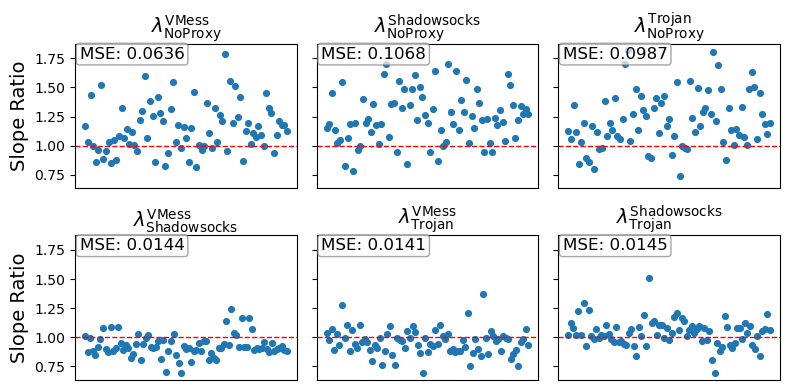

In [22]:
trojan_noproxy_slope_ratio = [r for trojan_slope, noproxy_slope in zip(slopes['trojan'], slopes['noproxy']) if (r := trojan_slope / noproxy_slope) <= 3]
vmess_noproxy_slope_ratio = [r for vmess_slope, noproxy_slope in zip(slopes['vmess'], slopes['noproxy']) if (r := vmess_slope / noproxy_slope) <= 3]
shadowsocks_noproxy_slope_ratio = [r for shadowsocks_slope, noproxy_slope in zip(slopes['shadowsocks'], slopes['noproxy']) if (r := shadowsocks_slope / noproxy_slope) <= 3]

vmess_shadowsocks_slope_ratio = [vmess_slope / shadowsocks_slope for vmess_slope, shadowsocks_slope in zip(slopes['vmess'], slopes['shadowsocks'])]
vmess_trojan_slope_ratio = [vmess_slope / trojan_slope for vmess_slope, trojan_slope in zip(slopes['vmess'], slopes['trojan'])]
shadowsocks_trojan_slope_ratio = [shadowsocks_slope / trojan_slope for shadowsocks_slope, trojan_slope in zip(slopes['shadowsocks'], slopes['trojan'])]

# Prepare all lists for plotting
ratio_lists = [
    (vmess_noproxy_slope_ratio, '$\lambda^{\\text{VMess}}_{\\text{NoProxy}}$'),
    (shadowsocks_noproxy_slope_ratio, '$\lambda^{\\text{Shadowsocks}}_{\\text{NoProxy}}$'),
    (trojan_noproxy_slope_ratio, '$\lambda^{\\text{Trojan}}_{\\text{NoProxy}}$'),
    (vmess_shadowsocks_slope_ratio, '$\lambda^{\\text{VMess}}_{\\text{Shadowsocks}}$'),
    (vmess_trojan_slope_ratio, '$\lambda^{\\text{VMess}}_{\\text{Trojan}}$'),
    (shadowsocks_trojan_slope_ratio, '$\lambda^{\\text{Shadowsocks}}_{\\text{Trojan}}$'),
]

fig, axs = plt.subplots(2, 3, figsize=(8, 4), sharey=True)
axs = axs.flatten()

for idx, (ratios, title) in enumerate(ratio_lists):
    axs[idx].scatter(range(len(ratios)), ratios, s=17)
    axs[idx].axhline(y=1, color='red', linestyle='--', linewidth=1)
    axs[idx].set_title(title, fontsize=14)
    axs[idx].set_xticks([])
    if idx % 3 == 0:
        axs[idx].set_ylabel('Slope Ratio', fontsize=14)
    axs[idx].set_xlabel('')

    # Compute MSE w.r.t. y=1 and annotate it on the upper left corner
    ratios_arr = np.array(ratios)
    mse = np.mean((ratios_arr - 1) ** 2)
    axs[idx].text(
        0.02, 0.98, f"MSE: {mse:.4f}", 
        transform=axs[idx].transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle="round,pad=0.2", facecolor='white', edgecolor='gray', alpha=0.7)
    )

plt.tight_layout()
plt.savefig('slope_ratio.pdf', bbox_inches='tight', dpi=300, format='pdf')

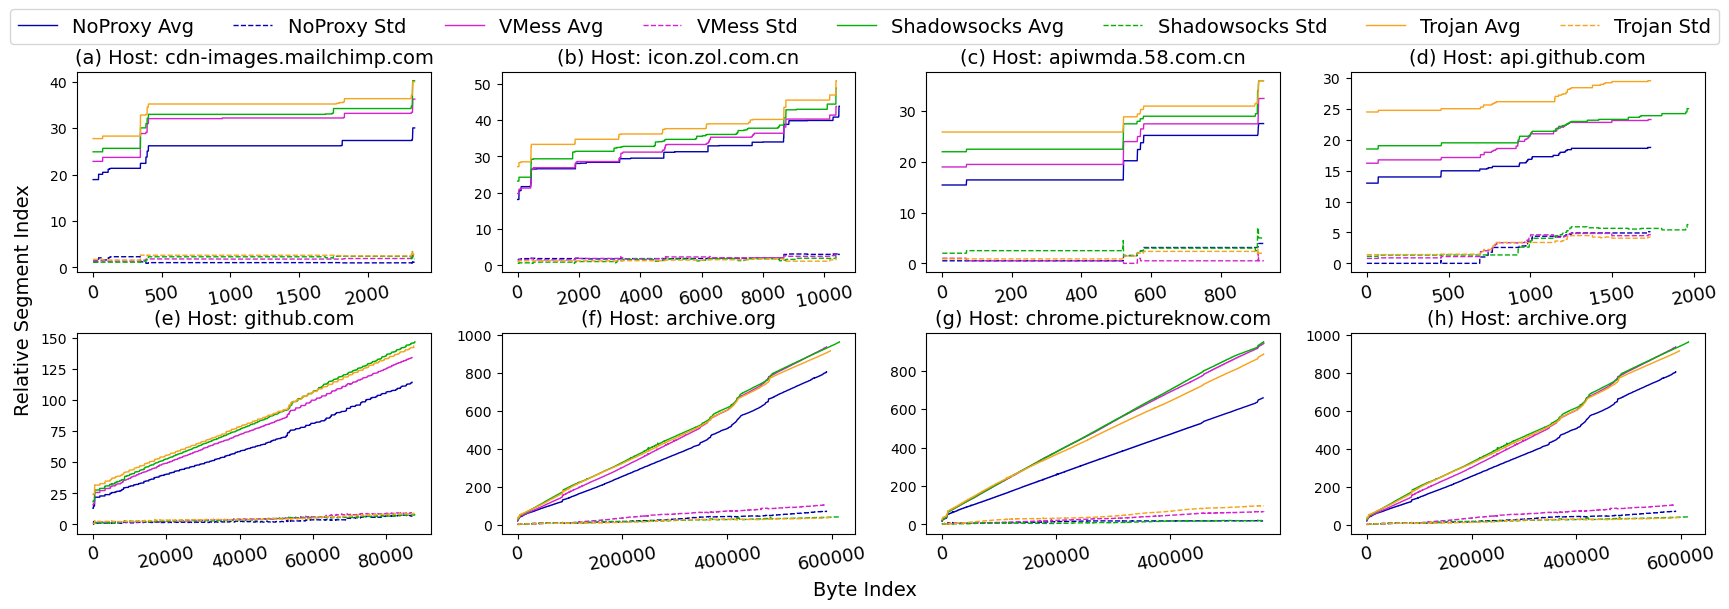

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

color_map = {"NoProxy": "#0300b0", "VMess": "#d422ce", "Shadowsocks": "#00b006", "Trojan": "#f7a31b"}
names = [
    [
        "ocw.mit.edu_cdn-images.mailchimp.com",  # Short
        "ask.zol.com.cn_icon.zol.com.cn",  # Short
        "ask.zol.com.cn_apiwmda.58.com.cn",  # Short
        "github.com_api.github.com"  # Short

    ],
    [
        "github.com_github.com",  # Long
        "archive.org_archive.org",  # Long
        "chrome.pictureknow.com_chrome.pictureknow.com",  # Long
        "archive.org_archive.org",  # Long
        # "openai.com_images.ctfassets.net",  # Long and split
        # "www.amazon.com_m.media-amazon.com", # Long and split
    ]
]

index = [
    ['a', 'b', 'c', 'd'],
    ['e', 'f', 'g', 'h'],
]

output_root = "/data/exp/lxyu/Dataset/WF/VisualSeg"
base = "tcp"


fig, axs = plt.subplots(2, 4, figsize=(21, 6))
# fig.suptitle('Byte Segment Map', fontdict={'size': 16})

for i, row in enumerate(names):
    for j, name in enumerate(row):
        for protocol in color_map:
            avg_array_path = Path(f"{output_root}/seg_compute/{base}/{protocol.lower()}/avg_{name}.npy")
            std_array_path = Path(f"{output_root}/seg_compute/{base}/{protocol.lower()}/std_{name}.npy")
            avg_byte_segments, std_byte_segments = np.load(avg_array_path), np.load(std_array_path)
            axs[i][j].plot(avg_byte_segments, linewidth=1, color=color_map[protocol], label=f"{protocol} Avg")
            axs[i][j].plot(std_byte_segments, linewidth=1, linestyle='--', color=color_map[protocol], label=f"{protocol} Std")
            # Remove per-subplot labels; set global labels after the loop
            host, sni = name.split('_')
            axs[i][j].set_title(f'({index[i][j]}) Host: {sni}', fontsize=14)
            # Change xticks font size to 10
            axs[i][j].tick_params(axis='x', labelsize=13, rotation=10)
            handles, labels = axs[i][j].get_legend_handles_labels()
            
fig.legend(handles, labels, loc='upper center', ncol=8, bbox_to_anchor=(0.5, 1), fontsize=14)
# Set global labels after the loop
fig.supxlabel('Byte Index', y=0.001, fontsize=14)
fig.supylabel('Relative Segment Index', x=0.095, fontsize=14)
fig.subplots_adjust(hspace=0.3)


fig.savefig('byte_segment_map.pdf', bbox_inches='tight', dpi=300, format='pdf')


In [ ]:
# BS filter
ss_bs_filter = [0.672, 0.678, 0.663, 0.670, 0.719, 0.722, 0.708, 0.703, 0.668]
tr_bs_filter = [0.502, 0.564, 0.561, 0.589, 0.411, 0.440, 0.463, 0.502, 0.517]

# BS filter strip
ss_bs_filter_strip = [0.732, 0.730, 0.746, 0.754, 0.738, 0.734, 0.720, 0.715, 0.679]
tr_bs_filter_strip = [0.598, 0.623, 0.634, 0.643, 0.416, 0.440, 0.455, 0.473, 0.517]

# No filter
ss = [0.510]
tr = [0.492]

# # SNI filter
# ss = [0.786]
# tr = [0.748]

# SNI filter strip
ss = [0.809]
tr = [0.805]

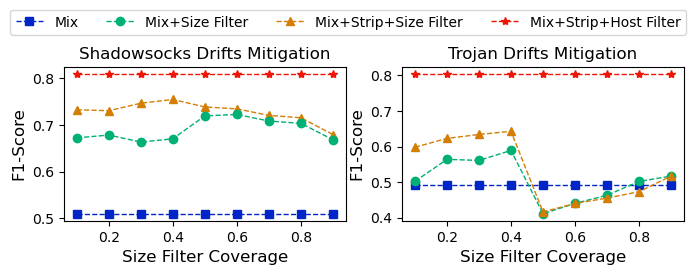

In [8]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(8, 2))
coverage = [0.1 * i for i in range(1, 10)]

ss_bs_filter = [0.672, 0.678, 0.663, 0.670, 0.719, 0.722, 0.708, 0.703, 0.668]
ss_bs_filter_strip = [0.732, 0.730, 0.746, 0.754, 0.738, 0.734, 0.720, 0.715, 0.679]
ss_no_filter = [0.510] * 9
ss_sni_filter_strip = [0.809] * 9

axs[0].plot(coverage, ss_sni_filter_strip, linewidth=1, color="#f01405", label=f"SNI Filter + Strip", marker='*', linestyle='--')
axs[0].plot(coverage, ss_bs_filter_strip, linewidth=1, color="#d47e05", label=f"Size Filter + Strip", marker='^', linestyle='--')
axs[0].plot(coverage, ss_bs_filter, linewidth=1, color="#00b075", label=f"Size Filter", marker='o', linestyle='--')
axs[0].plot(coverage, ss_no_filter, linewidth=1, color="#0125c6", label=f"No Filter", marker='s', linestyle='--')
axs[0].set_title('Shadowsocks Drifts Mitigation', fontsize=12)
handles, labels = axs[0].get_legend_handles_labels()
axs[0].set_xlabel('Size Filter Coverage', fontsize=12)
axs[0].set_ylabel('F1-Score', fontsize=12)

tr_bs_filter = [0.502, 0.564, 0.561, 0.589, 0.411, 0.440, 0.463, 0.502, 0.517]
tr_bs_filter_strip = [0.598, 0.623, 0.634, 0.643, 0.416, 0.440, 0.455, 0.473, 0.517]
tr_no_filter = [0.492] * 9
tr_sni_filter_strip = [0.805] * 9

axs[1].plot(coverage, tr_no_filter, linewidth=1, color="#0125c6", label=f"Mix", marker='s', linestyle='--')
axs[1].plot(coverage, tr_bs_filter, linewidth=1, color="#00b075", label=f"Mix+Size Filter", marker='o', linestyle='--')
axs[1].plot(coverage, tr_bs_filter_strip, linewidth=1, color="#d47e05", label=f"Mix+Strip+Size Filter", marker='^', linestyle='--')
axs[1].plot(coverage, tr_sni_filter_strip, linewidth=1, color="#f01405", label=f"Mix+Strip+Host Filter", marker='*', linestyle='--')

axs[1].set_title('Trojan Drifts Mitigation', fontsize=12)
handles, labels = axs[1].get_legend_handles_labels()
axs[1].set_xlabel('Size Filter Coverage', fontsize=12)
axs[1].set_ylabel('F1-Score', fontsize=12)

fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.48, 1.2), fontsize=10)
fig.savefig('mitigate.pdf', bbox_inches='tight', dpi=300, format='pdf')

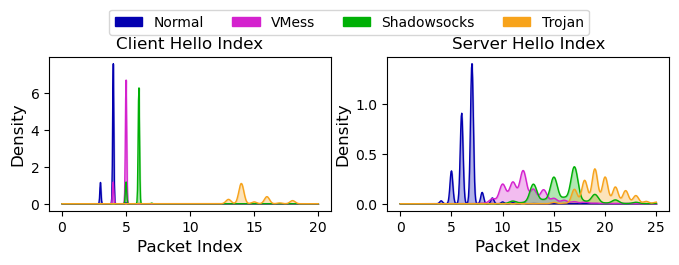

In [47]:
# Draw CH and SH indices
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from scipy import stats

fig, ax = plt.subplots(1, 2, figsize=(8, 2))

ch_df = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/ch_search/database.csv")
sh_df = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/sh_search/database.csv")

protocols = ['Normal', 'VMess', 'Shadowsocks', 'Trojan']
color_map = {"Normal": "#0300b0", "VMess": "#d422ce", "Shadowsocks": "#00b006", "Trojan": "#f7a31b"}

for protocol in protocols:
    data = ch_df.query(f"{protocol.lower()} >= 0")[protocol.lower()].tolist()
    hist, edges = np.histogram(data, bins=20, range=(0, 20), density=True)
    kde = stats.gaussian_kde(data)
    x_vals = np.linspace(min(edges), max(edges), 500)
    y_vals = kde(x_vals)
    ax[0].plot(x_vals, y_vals, color=color_map[protocol], label=protocol, linewidth=1)
    ax[0].fill_between(x_vals, y_vals, alpha=0.3, color=color_map[protocol])
    ax[0].set_xlabel('Packet Index', fontsize=12)
    ax[0].set_ylabel('Density', fontsize=12)
    ax[0].set_title('Client Hello Index', fontsize=12)

for protocol in protocols:
    data = sh_df.query(f"{protocol.lower()} >= 0")[protocol.lower()].tolist()
    hist, edges = np.histogram(data, bins=25, range=(0, 25), density=True)
    kde = stats.gaussian_kde(data)
    x_vals = np.linspace(min(edges), max(edges), 500)
    y_vals = kde(x_vals)
    ax[1].plot(x_vals, y_vals, color=color_map[protocol], label=protocol, linewidth=1)
    ax[1].fill_between(x_vals, y_vals, alpha=0.3, color=color_map[protocol])
    ax[1].set_xlabel('Packet Index', fontsize=12)
    ax[1].set_ylabel('Density', fontsize=12)
    ax[1].set_title('Server Hello Index', fontsize=12)

patches = [mpatches.Patch(color=color_map[protocol], label=protocol) for protocol in protocols]
fig.legend(handles=patches, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.15), fontsize=10)
fig.savefig('packet_index.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from WFlib.tools.formatter import array_path
from scipy.spatial.distance import pdist, squareform
import numpy as np

def avail_h2_diff(db: pd.DataFrame, proto_1: str, proto_2: str):
    db_1 = db.query(f"protocol == '{proto_1}'")[['host', 'SNI', 'avail_h2_avg']]
    db_2 = db.query(f"protocol == '{proto_2}'")[['host', 'SNI', 'avail_h2_avg']]

    # Find rows with the same SNI and compute noproxy_df['avail_h2_avg'] - vmess_df['avail_h2_avg']
    merged = pd.merge(db_1, db_2, on=['host', 'SNI'], suffixes=(f'_{proto_1}', f'_{proto_2}')).query(f"(avail_h2_avg_{proto_1} > 0) & (avail_h2_avg_{proto_2} > 0)")
    merged['avail_h2_diff'] = merged[f'avail_h2_avg_{proto_1}'] - merged[f'avail_h2_avg_{proto_2}']
    return merged


def protocol_stream_length(protocol, db):
    """
    Given the protocol and database, compute the average stream length for each SNI.
    """
    protocol_stream_length = dict()
    base_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/arrays"
    protocol_db = db.query(f"protocol == '{protocol}'")
    for host in protocol_db['host'].unique():
        host_db = protocol_db.query(f"host == '{host}'")
        for sni in host_db['sni'].unique(): 
            sni_db = host_db.query(f"sni == '{sni}'")
            paths = sni_db.apply(lambda row: f'{base_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
            for path in paths:
                stream_length = np.load(path)['direction'].shape[0]
                if stream_length > 40:  # Empirical length threshold for available HTTP stream 
                    if (host, sni) in protocol_stream_length:
                        protocol_stream_length[(host, sni)].append(stream_length)
                    else:
                        protocol_stream_length[(host, sni)] = [stream_length]
    return protocol_stream_length

def distance_correlation(X, Y):
    X = np.asarray(X).reshape(-1, 1)
    Y = np.asarray(Y).reshape(-1, 1)
    n = X.shape[0]

    a = squareform(pdist(X, 'euclidean'))
    b = squareform(pdist(Y, 'euclidean'))

    A = a - a.mean(axis=0) - a.mean(axis=1)[:, None] + a.mean()
    B = b - b.mean(axis=0) - b.mean(axis=1)[:, None] + b.mean()
    dcov2_xy = (A * B).sum() / (n * n)
    dcov2_xx = (A * A).sum() / (n * n)
    dcov2_yy = (B * B).sum() / (n * n)
    if dcov2_xx * dcov2_yy == 0:
        return 0.0
    return np.sqrt(dcov2_xy) / np.sqrt(np.sqrt(dcov2_xx) * np.sqrt(dcov2_yy))

In [25]:
stream_db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract/database.csv")
avail_h2_db = pd.read_csv("/data/exp/lxyu/Dataset/WF/VisualSeg/h2_stream_analysis/database.csv")

In [ ]:
import os

if os.path.exists("noproxy_stream_length.csv"):
    stream_length_df = pd.read_csv("noproxy_stream_length.csv")
else:
    stream_length = protocol_stream_length("normal", stream_db)
    # Take average on the value of stream_length
    stream_length = {k: np.mean(v) for k, v in stream_length.items()}

    # Convert dictionary to DataFrame with columns: host, SNI, avg_stream_length
    stream_length_df = pd.DataFrame([
        {'host': host, 'SNI': sni, 'avg_stream_length': avg_length}
        for (host, sni), avg_length in stream_length.items()
    ])

    stream_length_df.to_csv("noproxy_stream_length.csv", index=False)

In [27]:
# For Vmess vs noproxy
proto_1 = "vmess"
proto_2 = "noproxy"
merged_vmess_noproxy = avail_h2_diff(avail_h2_db, proto_1, proto_2)
merged_vmess_noproxy = pd.merge(merged_vmess_noproxy, stream_length_df, on=['host', 'SNI'])

# For Shadowsocks vs noproxy
proto_1 = "shadowsocks"
proto_2 = "noproxy"
merged_ss_noproxy = avail_h2_diff(avail_h2_db, proto_1, proto_2)
merged_ss_noproxy = pd.merge(merged_ss_noproxy, stream_length_df, on=['host', 'SNI'])

# For Trojan vs noproxy
proto_1 = "trojan"
proto_2 = "noproxy"
merged_trojan_noproxy = avail_h2_diff(avail_h2_db, proto_1, proto_2)
merged_trojan_noproxy = pd.merge(merged_trojan_noproxy, stream_length_df, on=['host', 'SNI'])

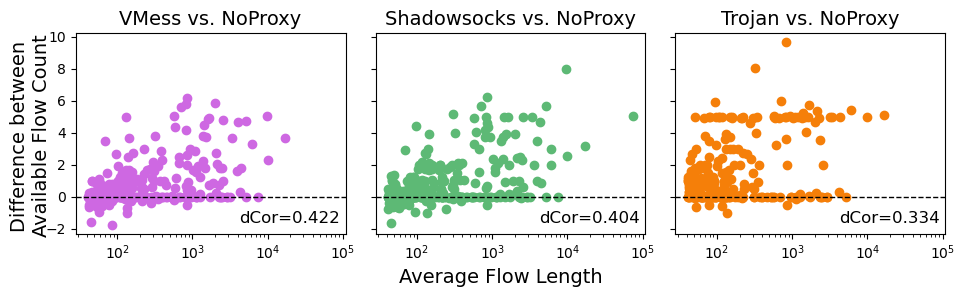

In [30]:
# Create a 1x3 figure for the three proxy protocols vs. noproxy, sharing x and y labels
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)
protocols = [
    ('VMess vs. NoProxy', merged_vmess_noproxy, "#CE68E2"),
    ('Shadowsocks vs. NoProxy', merged_ss_noproxy, "#5DB975"),
    ('Trojan vs. NoProxy', merged_trojan_noproxy, "#F57F09")
]

color_map = {"Normal": "#0300b0", "VMess": "#CE68E2", "Shadowsocks": "#5DB975", "Trojan": "#F57F09"}

for ax, (title, df, c) in zip(axes, protocols):
    ax.scatter(df['avg_stream_length'], df['avail_h2_diff'], c=c)
    ax.set_xscale('log')
    ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
    dcor = distance_correlation(df['avg_stream_length'], df['avail_h2_diff'])
    ax.set_title(title, fontsize=14)
    ax.annotate(f"dCor={dcor:.3f}", xy=(0.98, 0.04), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=12, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

# Set common labels
fig.text(0.53, 0.04, 'Average Flow Length', ha='center', fontsize=14)
fig.text(0.06, 0.53, 'Difference between\nAvailable Flow Count', va='center', ha='center', rotation='vertical', fontsize=14)
plt.tight_layout(rect=[0.06, 0.06, 1, 1])
fig.savefig('flow_split.pdf', bbox_inches='tight', dpi=300, format='pdf')